<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões e deformações na flexão pura

### Problema 7

Considere a viga ABCD com secção transversal de 120 $\times$ 60 mm $²$ indicada na figura. Represente os diagramas dos esforços internos e a distribuição das tensões normais na secção B, com a posição do eixo neutro e os valores máximo e mínimo da tensão normal.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P7/MSII_Au04_P7.png"
style="max-height: 100%; max-width: 100%;"/>

#### Dados do problema

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.L = 60.*1e-3  # unit: m
d.W = 120.*1e-3 # unit: m
d.AB = 1. # unit: m
d.BC = 1. # unit: m
d.CD = 1. # unit: m
d.Qy = 1.*1e3 # unit: N/m
d.Px = 1.*1e3 # unit: N/m
d.Pz = 5.*1e3 # unit: N/m

d.AC = d.AB + d.BC
d.AD = d.AC + d.CD

### Resolução

#### Propriedades de área da secção transversal

In [2]:
def irect(b,h): return b*h**3/12

Iz = irect(d.L,d.W)
print(f'Iz = {Iz:.3e} m⁴')
Iy = irect(d.W,d.L)
print(f'Iy = {Iy:.3e} m⁴')
A = d.L*d.W
print(f'A = {A:.3e} m²')

Iz = 8.640e-06 m⁴
Iy = 2.160e-06 m⁴
A = 7.200e-03 m²


#### Plano $x-y$

Nos apoios A e D desenvolvem forças de reação $R_{Ax}$, $R_{Ay}$ e $R_{Dy}$ (assumindo um sentido positivo das forças segundo o sentido positivo dos eixos do sistema de coordenads).

Nota: que o eixo $x$ é o eixo longitudinal enquanto que o eixo $y$ é vertical na secção.

- Análise do equilíbrio estático: Diagrama de corpo livre, cálculo das reações

In [3]:
rax, ray, rdy = sy.symbols('rax ray rdy')

print(f'System of Equations (x-y):\n--------------------------')
sumFx = rax - d.Px
print(f'sumFx = 0 : {sumFx} = 0 [N]')
sumFy = ray - d.Qy*d.AC + rdy
print(f'sumFy = 0 : {sumFy} = 0 [N]')
sumMAxy = - d.Qy*d.AC*(d.AC/2) + rdy*(d.AD)
print(f'sumMA = 0 : {sumMAxy} = 0 [N.m]')

System of Equations (x-y):
--------------------------
sumFx = 0 : rax - 1000.0 = 0 [N]
sumFy = 0 : ray + rdy - 2000.0 = 0 [N]
sumMA = 0 : 3.0*rdy - 2000.0 = 0 [N.m]


In [4]:
sol = solve({sumFx,sumFy,sumMAxy},{rax, ray, rdy})
print(f'\nSolution:\n---------')
RAx = sol[rax]; print(f'RAx = {RAx:.1f} [N]')
RAy = sol[ray]; print(f'RAy = {RAy:.1f} [N]')
RDy = sol[rdy]; print(f'RDy = {RDy:.1f} [N]')


Solution:
---------
RAx = 1000.0 [N]
RAy = 1333.3 [N]
RDy = 666.7 [N]


#### Plano $x-z$

Nos apoios A e D desenvolvem forças de reação $R_{Az}$ e $R_{Dz}$ (assumindo um sentido positivo das forças segundo o eixo positivo de $z$)

- Análise do equilíbrio estático: Diagrama de corpo livre, cálculo das reações

In [5]:
raz, rdz = sy.symbols('raz rdz')
print(f'System of Equations (x-z):\n--------------------------')
sumFz = raz - d.Pz + rdz
print(f'sumFz = 0 : {sumFz} = 0 [N]')
sumMAxz = - d.Pz*(d.AC) + rdz*(d.AD)
print(f'sumMA = 0 : {sumMAxz} = 0 [N.m]')

System of Equations (x-z):
--------------------------
sumFz = 0 : raz + rdz - 5000.0 = 0 [N]
sumMA = 0 : 3.0*rdz - 10000.0 = 0 [N.m]


In [6]:
sol = solve({sumFz,sumMAxz},{raz, rdz})
print(f'\nSolution:\n---------')
RAz = sol[raz]; print(f'RAz = {RAz:.1f} [N]')
RDz = sol[rdz]; print(f'RDz = {RDz:.1f} [N]')


Solution:
---------
RAz = 1666.7 [N]
RDz = 3333.3 [N]


#### Diagram de esforços: Método das secções, secção B

- Tramo AB:

Os sentidos dos esforços transverso e momento fletor invertem no corte à direita devido ao sentido negativo do eixo dos $z$. O valor obtido para o Momento fletos $M_{y,}aB$ é positivo mas de acordo com o eixo global $y$ o valor do momento é negativo.

In [7]:
nab, mzab, myab, x = sy.symbols('nab mzab myab x')

EQ_N_AB = rax + nab
NAB = solve(EQ_N_AB,nab)[0]
eval_NAB = NAB.subs({(rax,RAx),(x,d.AB)})
print(f'NAB(x)   = {NAB}                |   NAB(xB)  = {eval_NAB:.1f} [N]')

EQ_Mz_AB =  - ray*x + d.Qy*x*(x/2) + mzab
MzAB = solve(EQ_Mz_AB,mzab)[0]
eval_MzAB = MzAB.subs({(ray,RAy),(x,d.AB)})
print(f'MzAB(x)  = {MzAB}   |   MzAB(xB) = {eval_MzAB:.1f} [N.m]')

EQ_My_AB = raz*x + myab
MyAB = solve(EQ_My_AB,myab)[0]
eval_MyAB = MyAB.subs({(raz,RAz),(x,d.AB)})
print(f'MyAB(x)  = {MyAB}              |   MyAB(xB) = {eval_MyAB:.1f} [N.m]')

NAB(x)   = -rax                |   NAB(xB)  = -1000.0 [N]
MzAB(x)  = x*(ray - 500.0*x)   |   MzAB(xB) = 833.3 [N.m]
MyAB(x)  = -raz*x              |   MyAB(xB) = -1666.7 [N.m]


- Tensão normal:

A expressão da tensão normal combinada pelos efeitos do esforço normal e momentos fletores segundo $y$ e $z$ vem:

\begin{equation*}
\sigma_{xx} = \frac{(-N)}{A} - \frac{(+M_z)}{I_z}y + \frac{(-M_y)}{I_y} z
\end{equation*}

In [8]:
def printsym(expr):
    return expr.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

y, z, sigx = sy.symbols('y z sigx')

Eq = sigx - eval_NAB/A + eval_MzAB/Iz*y - eval_MyAB/Iy*z
print(f'solve(sxx = 0) : {printsym(Eq)} = 0')
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {printsym(sigxx*1e-6)} [MPa]')

solve(sxx = 0) : sigx + 96450617.284*y + 771604938.272*z + 138888.889 = 0
sigxx(y,z)  = -96.451*y - 771.605*z - 0.139 [MPa]


#### Visualização do campo de tensão 

(z,y) = (0.03, 0.06): Sxx(1) = -29.1 [MPa]
(z,y) = (-0.03, -0.06): Sxx(1) = 28.8 [MPa]


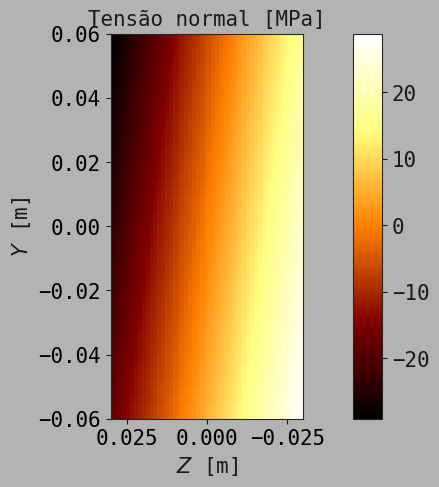

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

zsiz = np.linspace(d.L/2,-d.L/2)
ysiz = np.linspace(d.W/2,-d.W/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

#SxxMap = tensnormal(Y,Z)

edgey1, edgez1 = d.W/2, d.L/2
Sxx1 = tensnormal(edgey1, edgez1)*1e-6
print(f'(z,y) = {edgez1,edgey1}: Sxx(1) = {Sxx1:.1f} [MPa]')
edgey2, edgez2 = -d.W/2, -d.L/2
Sxx2 = tensnormal(edgey2, edgez2)*1e-6
print(f'(z,y) = {edgez2,edgey2}: Sxx(1) = {Sxx2:.1f} [MPa]')

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.L/2, -d.L/2, -d.W/2,d.W/2], cmap="afmhot")
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

- Orientação do eixo neutro

\begin{equation*}
\sigma_{xx} = \frac{(-N)}{A} - \frac{(+M_z)}{I_z}y + \frac{(-M_y)}{I_y} z = 0
\end{equation*}

y = -8.0*z - 0.00144 (recta geométrica do eixo neutro) [m]
z = -0.125*y - 0.00018 (recta geométrica do eixo neutro) [m]


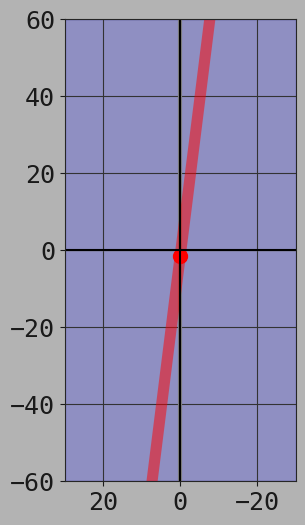

In [10]:
from matplotlib.patches import Rectangle

yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

zplo_mm = np.linspace(d.L/2,-d.L/2)*1e3
yplo_mm = np.zeros(len(zplo_mm))
for i in range(0,len(zplo_mm)):
    yplo_mm[i] = yzfun.subs(z,zplo_mm[i]*1e-3)*1e3

fig, ax = plt.subplots(figsize=(12,6))
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle((-d.L/2*1e3, -d.W/2*1e3), d.L*1e3, d.W*1e3,color="blue",alpha=0.2))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
ax.plot(0,yzfun.subs(z,0)*1e3,'or',markersize=10)
plt.plot(zplo_mm,yplo_mm,'r-',linewidth=8,alpha=0.5)
ax.invert_xaxis()
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.xlim([d.L*1e3*.5, -d.L*1e3*.5])
plt.ylim([-d.W*1e3*.5, d.W*1e3*.5])
ax.set_aspect('equal')
plt.grid(True)
plt.show()

- Qual a influência do carregamento na distribuição da tensão normal ao longo da secção?

\begin{equation*}
\begin{aligned}
Q_y &\longrightarrow M_z \\
iP_x &\longrightarrow N \\
iP_z &\longrightarrow M_y
\end{aligned}
\end{equation*}

In [13]:
from ipywidgets import interactive

fzp = 15

def itplot(iQy,iPx,iPz):

    rax, ray, rdy = sy.symbols('rax r806.50ay rdy')
    sumFx = rax - iPx
    sumFy = ray - iQy*d.AC + rdy
    sumMAxy = - iQy*d.AC*(d.AC/2) + rdy*(d.AD)
    sol = solve({sumFx,sumFy,sumMAxy},{rax, ray, rdy})
    RAx, RAy, RDy = sol[rax], sol[ray], sol[rdy]

    raz, rdz = sy.symbols('raz rdz')
    sumFz = raz - iPz + rdz
    sumMAxz = - iPz*(d.AC) + rdz*(d.AD)
    sol = solve({sumFz,sumMAxz},{raz, rdz})
    RAz, RDz = sol[raz], sol[rdz]

    nab, mzab, myab, x = sy.symbols('nab mzab myab x')
    EQ_N_AB = rax + nab
    NAB = solve(EQ_N_AB,nab)[0]
    eval_NAB = NAB.subs({(rax,RAx),(x,d.AB)})
    EQ_Mz_AB = ray*x - iQy*x*(x/2) + mzab
    MzAB = solve(EQ_Mz_AB,mzab)[0]
    eval_MzAB = MzAB.subs({(ray,RAy),(x,d.AB)})
    EQ_My_AB = raz*x + myab
    MyAB = solve(EQ_My_AB,myab)[0]
    eval_MyAB = MyAB.subs({(raz,RAz),(x,d.AB)})

    y, z, sigx = sy.symbols('y z sigx')
    Eq = sigx + eval_NAB/A + eval_MzAB/Iz*y - eval_MyAB/Iy*z
    sigxx = solve(Eq,sigx)[0]

    zsiz = np.linspace(d.L/2,-d.L/2)
    ysiz = np.linspace(d.W/2,-d.W/2)
    Z, Y = np.meshgrid(zsiz, ysiz)

    def tensnormal(y2,z2):
        return sigxx.subs({(y,y2),(z,z2)}) 

    SxxMap = np.zeros(np.shape(Z))
    for i in range(0,len(ysiz)):
        for j in range(0,len(zsiz)):
            SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

    #fig = plt.figure(figsize=(10, 5))
    fig = plt.figure()
    ax  = plt.gca()
    ttl = plt.title('Tensão normal [MPa]',fontsize=15)
    ttl.set_position([0.5, 1.05])
    plt.ylabel(r'$Y$ [m]',fontsize=fzp)
    plt.xlabel(r'$Z$ [m]',fontsize=fzp)
    im = ax.imshow(SxxMap*1e-6, extent=[d.L/2, -d.L/2, -d.W/2,d.W/2], cmap="afmhot")
    plt.xticks(color ='k', size=fzp)
    plt.yticks(color ='k', size=fzp)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="15%", pad=0.5)
    cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
    cbar.ax.tick_params(labelsize=fzp)
    plt.show()

    yzfun = solve(sigxx,y)[0]
    zplo_mm = np.linspace(d.L/2,-d.L/2)*1e3
    yplo_mm = np.zeros(len(zplo_mm))
    for i in range(0,len(zplo_mm)):
        yplo_mm[i] = yzfun.subs(z,zplo_mm[i]*1e-3)*1e3

    #fig, ax = plt.subplots(figsize=(12,6))
    fig, ax = plt.subplots()
    ax.plot([0],[0],color="black")
    ax.add_patch(Rectangle((-d.L/2*1e3, -d.W/2*1e3), d.L*1e3, d.W*1e3,color="blue",alpha=0.2))
    plt.axhline(linewidth=1,color=(.5, .5, .5))
    plt.axvline(linewidth=3,color=(.5, .5, .5))
    ax.plot(0,yzfun.subs(z,0)*1e3,'or',markersize=10)
    plt.plot(zplo_mm,yplo_mm,'r-',linewidth=8,alpha=0.5)
    ax.invert_xaxis()
    plt.axhline(y=0, color='k')
    plt.axvline(x=0, color='k')
    plt.xlim([d.L*1e3*.5, -d.L*1e3*.5])
    plt.ylim([-d.W*1e3*.5, d.W*1e3*.5])
    ax.set_aspect('equal')
    plt.grid(True)
    plt.show()

interactive_plot = interactive(itplot, iQy=(-1e4, 1e4), iPx=(-2.2e4,2.2e4), iPz=(-1e4,1e4))
output = interactive_plot.children[-1]
output.layout.height = '800px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='iQy', max=10000.0, min=-10000.0), FloatSlider(value=…

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>